<a href="https://colab.research.google.com/github/FachrizaFajri/UTS-DATA-MINING/blob/main/UTS_FACHRIZA_KHAIRUL_FAJRI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


### Decision Tree Untuk Klasifikasi Berat Badan Obesitas | Machine Learning

Pada analisis project ini, akan dilakukan proses klasifikasi atau pembangunan model machine learning, yang lebih spesifiknya menggunakan algoritma Decision Tree (pohon keputusan). Model ini akan dibangun dengan menggunakan data sampel yang berkaitan dengan obesitas, khususnya data berat badan dan tinggi badan seseorang. Berdasarkan data tersebut, model diharapkan mampu mengklasifikasikan apakah seseorang terindikasi mengalami obesitas atau tidak.

Dataset yang di gunakan adalah https://drive.google.com/filed/1fseo9YAXrC2rGEvfLOWCt43abySJtspn/view?usp=drive_link berdasarkan data berat badan dan tinggi badan, dapat dilakukan penentuan apakah seseorang didiagnosis mengalami obesitas atau tidak

## IMPORT LIBRARY YANG AKAN DIGUNAKAN


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier as arn
from sklearn.metrics import classification_report

## 1.IMPORT DATA


Label

0-xtreme weak

1-weak

2-Normal

3-overweight

4-obesity

5-overobesity




In [ ]:
df = pd.read_csv("/content/drive/MyDrive/latihan data mining/bmi.csv",index_col=0)
df

,Jenis Kelamin,Tinggi Badan,Berat Badan,Label
0,Laki laki,174,96,4
1,Laki laki,189,87,2
2,Perempuan,185,110,4
3,Perempuan,195,104,3
4,Laki laki,149,61,3
...,...,...,...,...
495,Perempuan,150,153,5
496,Perempuan,184,121,4
497,Perempuan,141,136,5
498,Laki laki,150,95,5


In [ ]:
df.head()

,Jenis Kelamin,Tinggi Badan,Berat Badan,Label
0,Laki laki,174,96,4
1,Laki laki,189,87,2
2,Perempuan,185,110,4
3,Perempuan,195,104,3
4,Laki laki,149,61,3


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Jenis Kelamin  500 non-null    object
 1   Tinggi Badan   500 non-null    int64 
 2   Berat Badan    500 non-null    int64 
 3   Label          500 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 19.5+ KB


In [ ]:
df.shape

(500, 4)

Jumalah baris data tersebut ada 500 dengan 4 atribut

In [ ]:
df.Label.value_counts()

,count
Label,
5,198
4,130
2,69
3,68
1,22
0,13


## 2.CLEANING DATA

In [ ]:
df.isnull().sum()

,0
Jenis Kelamin,0
Tinggi Badan,0
Berat Badan,0
Label,0


In [ ]:
df.duplicated().sum()

np.int64(11)

Terdapat 11 baris yang sama atau duplicate dan itu akan menggangu model ini, data duplicate tersebut akan di hilangan dengal kode di bawah ini

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.shape

(489, 4)

setelah di hilangkan data duplicate nya jumlah barisnya berkurang menjadi 489 baris

## 3.EXPLORATORY DATA ANALYS(EDA)

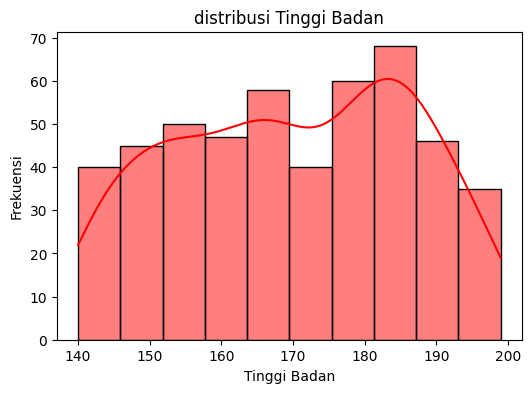

In [ ]:
plt.figure(figsize=(6, 4 ))
sns.histplot (data=df, x='Tinggi Badan', bins=10, kde=True,color='red')

plt.title('distribusi Tinggi Badan')
plt.xlabel('Tinggi Badan')
plt.ylabel('Frekuensi')
plt.show()

Distribusi tinggibadan terttinggi berada disekitar 181-187 cm, dan terendahnya ada disekitar 193-198 cm

In [21]:
fig=px.sunburst(df,path=['Jenis Kelamin','Label'], values=df.value_counts().values,color_discrete_sequence=['#2BCDC1','#F66095'])
fig.show()

## 4.PREPARATION DATA

In [ ]:
from sklearn.preprocessing import LabelEncoder
jkencoder = LabelEncoder()
df['Jenis Kelamin'] = jkencoder.fit_transform(df['Jenis Kelamin'])

<ipython-input-16-aebc6d787834>:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
df.head()

,Jenis Kelamin,Tinggi Badan,Berat Badan,Label
0,0,174,96,4
1,0,189,87,2
2,1,185,110,4
3,1,195,104,3
4,0,149,61,3


Tipe data pada kolom jenis kelamin sudah di ubah agar mempermudah proses,yang dimana angka 0 merepresentasikan sebagai laki laki dan 1 sebagai perempuan

In [ ]:
x = df.drop(columns=['Label'])
y = df['Label']

print ("x : ", x.shape)
print ("y : ", y.shape)

x :  (489, 3)
y :  (489,)


In [ ]:
scaler = StandardScaler()
scaler.fit(x)
x = scaler.transform(x)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

## Modeling & Evaluation

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

clf = arn()
clf.fit(x_train, y_train)

y_pred = clf.predict(x_test)

decision_tree_acc = accuracy_score(y_test, y_pred)

print(classification_report(y_test, y_pred))
print('akurasi model decision tree : {:.2f}%'.format (decision_tree_acc * 100))

              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.33      0.50      0.40         2
           2       0.75      0.80      0.77        15
           3       0.60      0.67      0.63         9
           4       0.86      0.74      0.79        34
           5       0.87      0.94      0.91        36

    accuracy                           0.81        98
   macro avg       0.74      0.69      0.70        98
weighted avg       0.82      0.81      0.81        98

akurasi model decision tree : 80.61%


Disini akurasi model decision tree yang saya bangun ada di 0,81 atau bisa dibulatkan menjadi 81% yang dimana akang itu lumayan tinggi

## Testing

In [ ]:
new_data = pd.DataFrame({
    'Jenis Kelamin': ["Perempuan"],
    'Tinggi Badan': [188],
    'Berat Badan': [70]
})

In [ ]:
new_data ['Jenis Kelamin'] = jkencoder.transform(new_data['Jenis Kelamin'])

In [ ]:
new_data_scaled = scaler.transform(new_data)
prediction = clf.predict(new_data_scaled)
print('pdesiksi BMI:', prediction [0])

pdesiksi BMI: 2


Pada testing ini menggunaka contoh yang berjenis kelamin perempuang dengan tinggi badan 188 dan berat badan 70 dan dia termasul labe ke 2 yang dimana label 2 itu artinya normal

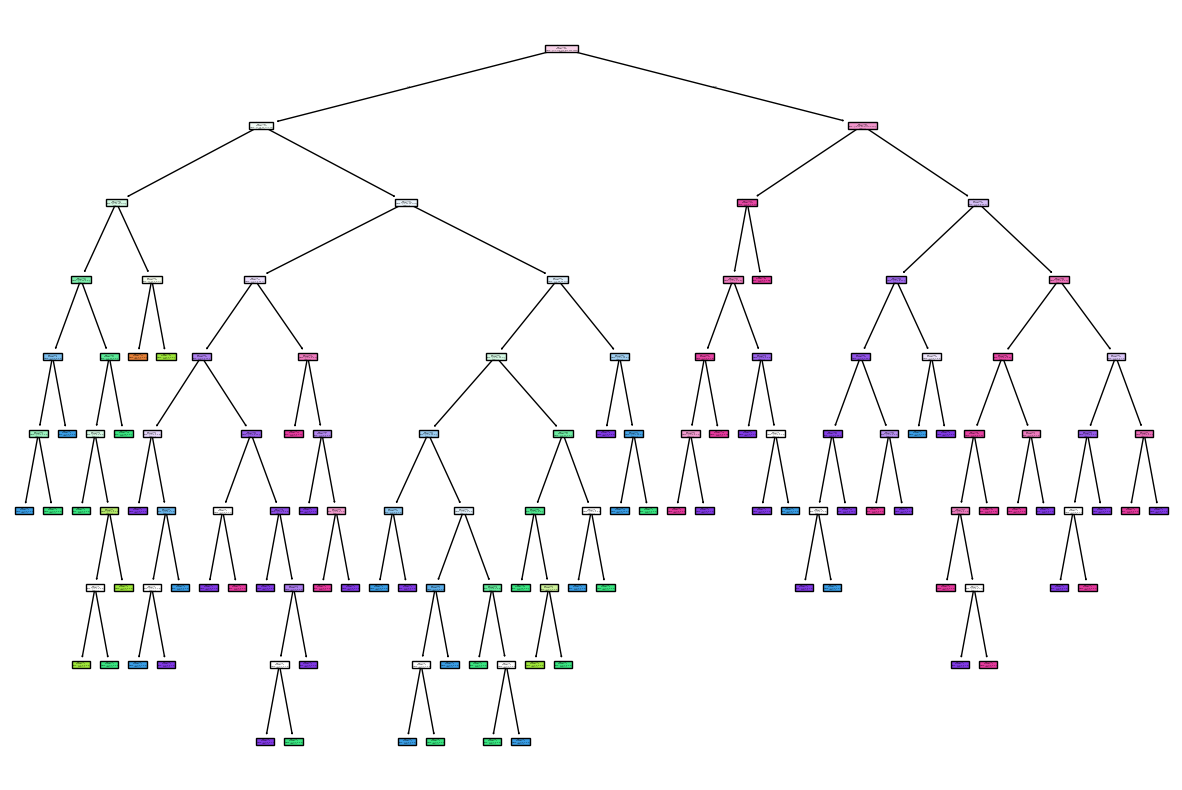

In [ ]:
from sklearn import tree
fig = plt.figure(figsize = (15, 10))
atribut = df.drop(columns=['Label']).columns
label = clf.classes_
label = [str(i) for i in label]
dtree = clf
tree.plot_tree(dtree, feature_names=atribut, class_names=label, filled=True)
plt.show()